# TEMPO vs TROPOMI Tropospheric NO2 Comparison

In [4]:
import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr
from IPython.display import Image, display

# First run only: ee.Authenticate() opens a browser consent screen and caches credentials locally.
# ee.Authenticate()
ee.Initialize(project='applied-remote-sensing-485001')

In [5]:
study_area = ee.Geometry.Rectangle([-91.5, 29.5, -90.0, 31.0])
palette = ['440154', '482878', '3e4989', '31688e', '26828e',
           '1f9e89', '35b779', '6ece58', 'b5de2b', 'fde725']

## Helper functions

In [6]:
def mask_tropomi(img):
    mask = img.select('cloud_fraction').lt(0.5)
    return img.updateMask(mask).select('tropospheric_NO2_column_number_density')


def aggregate_tempo(tempo_img, target_proj):
    return (tempo_img
            .setDefaultProjection(crs='EPSG:4326', scale=2000)
            .reduceResolution(reducer=ee.Reducer.mean(), maxPixels=256)
            .reproject(crs=target_proj, scale=5500))


def normalize_img(img, band_name, geometry):
    stats = img.reduceRegion(reducer=ee.Reducer.minMax(), geometry=geometry,
                              scale=2000, maxPixels=1e9)
    lo = ee.Number(stats.get(band_name + '_min'))
    hi = ee.Number(stats.get(band_name + '_max'))
    return img.subtract(lo).divide(hi.subtract(lo))


def fc_to_df(fc, columns=None):
    features = fc.getInfo()['features']
    df = pd.DataFrame([f['properties'] for f in features])
    return df[columns] if columns else df

## Shared TROPOMI projection

In [7]:
tropomi_proj = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_NO2')
                .filterDate('2024-11-01', '2024-11-30')
                .first()
                .select('tropospheric_NO2_column_number_density')
                .projection())

## Scatter plot helper

In [8]:
def plot_scatter(df, title, color, xmax=70, ymax=10):
    x, y = df['tempo'].values, df['tropomi'].values
    slope, intercept, r, p, se = linregress(x, y)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(x, y, s=20, alpha=0.6, color=color)
    xs = np.linspace(0, xmax, 100)
    ax.plot(xs, slope * xs + intercept, color='black', linewidth=1, alpha=0.8,
            label=f'R\u00b2 = {r**2:.3f}')
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax)
    ax.set_xlabel('TEMPO (\u00d710\u00b9\u2074 molecules/cm\u00b2)')
    ax.set_ylabel('TROPOMI (\u00d710\u00b9\u2074 molecules/cm\u00b2)')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return slope, intercept, r, p

## Single day (Nov 15, 2024)

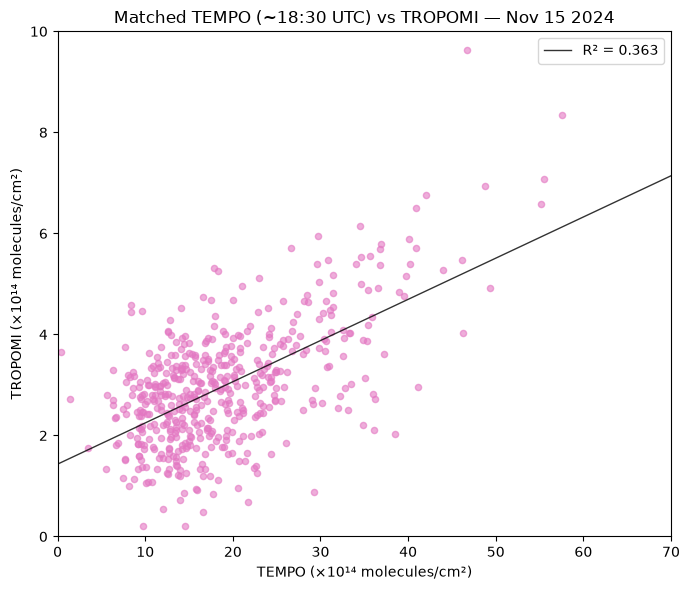

(np.float64(0.08153411631269085),
 np.float64(1.4329564288617056),
 np.float64(0.6023427991788116),
 np.float64(8.615054860002316e-51))

In [9]:
tempo_day = (ee.ImageCollection('NASA/TEMPO/NO2_L3_QA')
             .filterDate('2024-11-15T18:00', '2024-11-15T19:00')
             .filterBounds(study_area)
             .select('vertical_column_troposphere')
             .mean())

tropomi_day = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_NO2')
               .filterDate('2024-11-15', '2024-11-16')
               .filterBounds(study_area)
               .map(mask_tropomi)
               .mean()
               .multiply(6.022e19)
               .reproject(crs=tropomi_proj, scale=5500))

tempo_day_agg = aggregate_tempo(tempo_day, tropomi_proj)

sample_day_fc = (tempo_day_agg.divide(1e14).rename('tempo')
                  .addBands(tropomi_day.divide(1e14).rename('tropomi'))
                  .sample(region=study_area, scale=5500, numPixels=500))

sample_day = fc_to_df(sample_day_fc, columns=['tempo', 'tropomi'])
plot_scatter(sample_day, 'Matched TEMPO (~18:30 UTC) vs TROPOMI \u2014 Nov 15 2024', color='#e377c2')

## Monthly aggregate (Nov 2024)

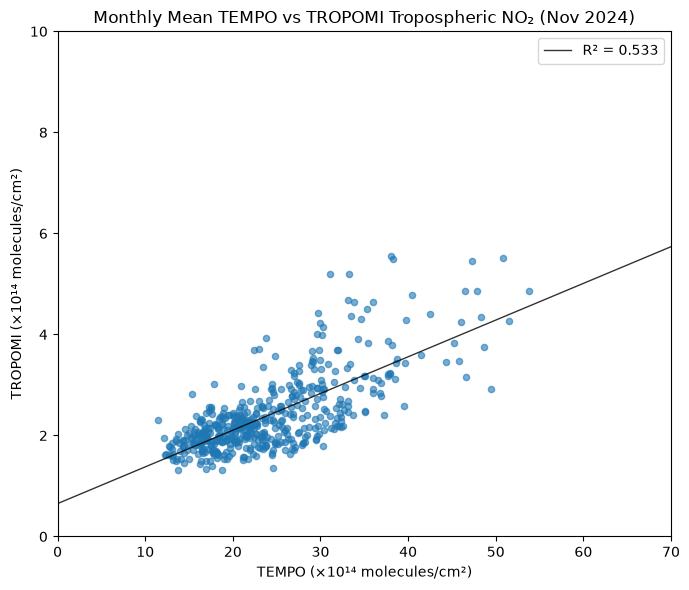

(np.float64(0.07264426284007214),
 np.float64(0.651781834018013),
 np.float64(0.7304084788695253),
 np.float64(1.1685307221365217e-84))

In [10]:
tempo_monthly = (ee.ImageCollection('NASA/TEMPO/NO2_L3_QA')
                  .filterDate('2024-11-01', '2024-11-30')
                  .filterBounds(study_area)
                  .mean()
                  .select('vertical_column_troposphere'))

tropomi_monthly = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_NO2')
                    .filterDate('2024-11-01', '2024-11-30')
                    .filterBounds(study_area)
                    .map(mask_tropomi)
                    .mean()
                    .multiply(6.022e19)
                    .reproject(crs=tropomi_proj, scale=5500))

tempo_monthly_agg = aggregate_tempo(tempo_monthly, tropomi_proj)

sample_monthly_fc = (tempo_monthly_agg.divide(1e14).rename('tempo')
                      .addBands(tropomi_monthly.divide(1e14).rename('tropomi'))
                      .sample(region=study_area, scale=5500, numPixels=500))

sample_monthly = fc_to_df(sample_monthly_fc, columns=['tempo', 'tropomi'])
plot_scatter(sample_monthly, 'Monthly Mean TEMPO vs TROPOMI Tropospheric NO\u2082 (Nov 2024)', color='#1f77b4')

## Annual aggregate (2024)

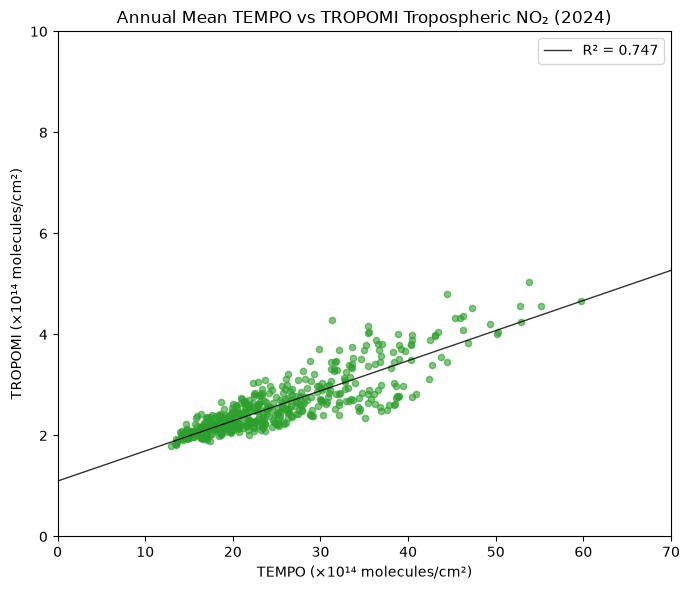

(np.float64(0.05956838715196664),
 np.float64(1.0976905186421246),
 np.float64(0.8644159759785546),
 np.float64(4.000504160869814e-151))

In [11]:
tempo_annual = (ee.ImageCollection('NASA/TEMPO/NO2_L3_QA')
                .filterDate('2024-01-01', '2024-12-31')
                .filterBounds(study_area)
                .mean()
                .select('vertical_column_troposphere'))

tropomi_annual = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_NO2')
                   .filterDate('2024-01-01', '2024-12-31')
                   .filterBounds(study_area)
                   .map(mask_tropomi)
                   .mean()
                   .multiply(6.022e19)
                   .reproject(crs=tropomi_proj, scale=5500))

tempo_annual_agg = aggregate_tempo(tempo_annual, tropomi_proj)

sample_annual_fc = (tempo_annual_agg.divide(1e14).rename('tempo')
                     .addBands(tropomi_annual.divide(1e14).rename('tropomi'))
                     .sample(region=study_area, scale=5500, numPixels=500))

sample_annual = fc_to_df(sample_annual_fc, columns=['tempo', 'tropomi'])
plot_scatter(sample_annual, 'Annual Mean TEMPO vs TROPOMI Tropospheric NO\u2082 (2024)', color='#2ca02c')

## Normalized differences

In [12]:
tropomi_day_at_tempo_res = tropomi_day.reproject(crs='EPSG:4326', scale=2000)
tempo_day_scaled = normalize_img(tempo_day, 'vertical_column_troposphere', study_area)
tropomi_day_scaled = normalize_img(tropomi_day_at_tempo_res, 'tropospheric_NO2_column_number_density', study_area)
diff_norm_day = tempo_day_scaled.subtract(tropomi_day_scaled)

tropomi_monthly_at_tempo_res = tropomi_monthly.reproject(crs='EPSG:4326', scale=2000)
tempo_monthly_scaled = normalize_img(tempo_monthly, 'vertical_column_troposphere', study_area)
tropomi_monthly_scaled = normalize_img(tropomi_monthly_at_tempo_res, 'tropospheric_NO2_column_number_density', study_area)
diff_norm_monthly = tempo_monthly_scaled.subtract(tropomi_monthly_scaled)

tropomi_annual_at_tempo_res = tropomi_annual.reproject(crs='EPSG:4326', scale=2000)
tempo_annual_scaled = normalize_img(tempo_annual, 'vertical_column_troposphere', study_area)
tropomi_annual_scaled = normalize_img(tropomi_annual_at_tempo_res, 'tropospheric_NO2_column_number_density', study_area)
diff_norm_annual = tempo_annual_scaled.subtract(tropomi_annual_scaled)

## Interactive map

In [13]:
Map = geemap.Map()
Map.centerObject(study_area, 8)

norm_vis = {'min': 0, 'max': 1, 'palette': palette}
diff_vis = {'min': -1, 'max': 1, 'palette': ['blue', 'white', 'red']}

Map.addLayer(ee.Image(1).clip(study_area), {'opacity': 0.35, 'palette': ['red']}, 'Study Area')

Map.addLayer(tropomi_day_scaled.clip(study_area), norm_vis, 'Nov 15 | TROPOMI NO\u2082 (normalized)')
Map.addLayer(tempo_day_scaled.clip(study_area), norm_vis, 'Nov 15 | TEMPO NO\u2082 (normalized)')

Map.addLayer(tropomi_monthly_scaled.clip(study_area), norm_vis, 'Nov 2024 | TROPOMI NO\u2082 (normalized)')
Map.addLayer(tempo_monthly_scaled.clip(study_area), norm_vis, 'Nov 2024 | TEMPO NO\u2082 (normalized)')

Map.addLayer(tropomi_annual_scaled.clip(study_area), norm_vis, '2024 Annual | TROPOMI NO\u2082 (normalized)')
Map.addLayer(tempo_annual_scaled.clip(study_area), norm_vis, '2024 Annual | TEMPO NO\u2082 (normalized)')

Map.addLayer(diff_norm_day.clip(study_area), diff_vis, 'Nov 15 | Normalized difference (TEMPO \u2212 TROPOMI)')
Map.addLayer(diff_norm_monthly.clip(study_area), diff_vis, 'Nov 2024 | Normalized difference (TEMPO \u2212 TROPOMI)')
Map.addLayer(diff_norm_annual.clip(study_area), diff_vis, '2024 Annual | Normalized difference (TEMPO \u2212 TROPOMI)')

Map

Map(center=[30.25022704436451, -90.75000000000001], controls=(WidgetControl(options=['position', 'transparent_…

## Hourly time series (June 15, 2024)

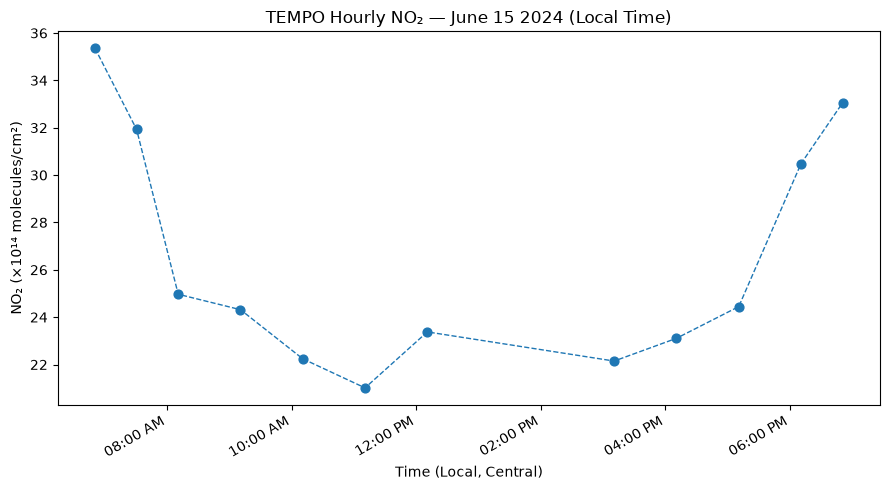

In [16]:
import matplotlib.dates as mdates

hourly_ic = (ee.ImageCollection('NASA/TEMPO/NO2_L3_QA')
             .filterDate('2024-06-15T05:00', '2024-06-16T05:00')
             .filterBounds(study_area)
             .select('vertical_column_troposphere'))


def with_region_mean(img):
    stat = img.reduceRegion(reducer=ee.Reducer.mean(), geometry=study_area,
                             scale=2000, maxPixels=1e9)
    return img.set('mean_no2', stat.get('vertical_column_troposphere'))


hourly_with_stats = hourly_ic.map(with_region_mean)

# Pull time + mean as paired rows in one call — a fully-masked scene drops its
# 'mean_no2' property, which desyncs two separate aggregate_array() calls.
rows = hourly_with_stats.reduceColumns(
    reducer=ee.Reducer.toList(2),
    selectors=['system:time_start', 'mean_no2']
).get('list').getInfo()

LOCAL_TZ = 'America/Chicago'  # Louisiana Gulf Coast study area

hourly_df = pd.DataFrame(rows, columns=['time_ms', 'no2'])
hourly_df['time'] = pd.to_datetime(hourly_df['time_ms'], unit='ms', utc=True).dt.tz_convert(LOCAL_TZ)
hourly_df['no2'] = pd.to_numeric(hourly_df['no2'], errors='coerce') / 1e14
hourly_df = hourly_df.dropna(subset=['no2']).sort_values('time')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hourly_df['time'], hourly_df['no2'], color='#1f77b4', linewidth=1, linestyle='--')
ax.scatter(hourly_df['time'], hourly_df['no2'], color='#1f77b4', s=40)
ax.set_xlabel('Time (Local, Central)')
ax.set_ylabel('NO₂ (×10¹⁴ molecules/cm²)')
ax.set_title('TEMPO Hourly NO₂ — June 15 2024 (Local Time)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%I:%M %p', tz=hourly_df['time'].dt.tz))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [17]:
scan_times = (ee.ImageCollection('NASA/TEMPO/NO2_L3_QA')
              .filterDate('2024-06-15', '2024-06-16')
              .filterBounds(study_area)
              .aggregate_array('system:time_start')
              .getInfo())
print('June 15 scan times (local):',
      [pd.to_datetime(t, unit='ms', utc=True).tz_convert(LOCAL_TZ).strftime('%I:%M %p') for t in scan_times])

June 15 scan times (local): ['07:00 PM', '05:30 AM', '06:10 AM', '06:50 AM', '07:30 AM', '08:10 AM', '09:10 AM', '10:10 AM', '11:10 AM', '12:10 PM', '03:01 PM', '03:10 PM', '04:10 PM', '05:10 PM', '06:10 PM', '06:50 PM']


## Summary statistics

In [18]:
def print_diff_stats(label, diff_img, band='vertical_column_troposphere', scale=2000):
    reducer = (ee.Reducer.mean()
               .combine(ee.Reducer.stdDev(), sharedInputs=True)
               .combine(ee.Reducer.percentile([5, 50, 95]), sharedInputs=True))
    stats = diff_img.reduceRegion(reducer=reducer, geometry=study_area,
                                   scale=scale, maxPixels=1e9).getInfo()
    print(f"{label} | mean: {stats[band + '_mean']:.3f} "
          f"| sd: {stats[band + '_stdDev']:.3f} "
          f"| p5: {stats[band + '_p5']:.3f} "
          f"| p50: {stats[band + '_p50']:.3f} "
          f"| p95: {stats[band + '_p95']:.3f}")

    frac = diff_img.gt(0).reduceRegion(reducer=ee.Reducer.mean(), geometry=study_area,
                                        scale=scale, maxPixels=1e9).getInfo()
    print(f"{label} | TEMPO > TROPOMI: {frac[band] * 100:.1f}%")


def print_corr(label, df):
    slope, intercept, r, p, se = linregress(df['tempo'], df['tropomi'])
    print(f"{label} | scale: {slope:.4f}, offset: {intercept:.4f}")
    print(f"{label} | R: {r:.4f} (p = {p:.2e})")

In [19]:
print_diff_stats('Nov 15 2024   ', diff_norm_day)
print_corr('Nov 15 2024   ', sample_day)

print_diff_stats('Nov 2024      ', diff_norm_monthly)
print_corr('Nov 2024      ', sample_monthly)

print_diff_stats('2024 Annual   ', diff_norm_annual)
print_corr('2024 Annual   ', sample_annual)

Nov 15 2024    | mean: -0.077 | sd: 0.114 | p5: -0.254 | p50: -0.082 | p95: 0.106
Nov 15 2024    | TEMPO > TROPOMI: 23.6%
Nov 15 2024    | scale: 0.0815, offset: 1.4330
Nov 15 2024    | R: 0.6023 (p = 8.62e-51)
Nov 2024       | mean: 0.006 | sd: 0.123 | p5: -0.184 | p50: -0.004 | p95: 0.207
Nov 2024       | TEMPO > TROPOMI: 49.2%
Nov 2024       | scale: 0.0726, offset: 0.6518
Nov 2024       | R: 0.7304 (p = 1.17e-84)
2024 Annual    | mean: -0.032 | sd: 0.089 | p5: -0.190 | p50: -0.025 | p95: 0.108
2024 Annual    | TEMPO > TROPOMI: 33.5%
2024 Annual    | scale: 0.0596, offset: 1.0977
2024 Annual    | R: 0.8644 (p = 4.00e-151)


## Thumbnails

KeyboardInterrupt: 

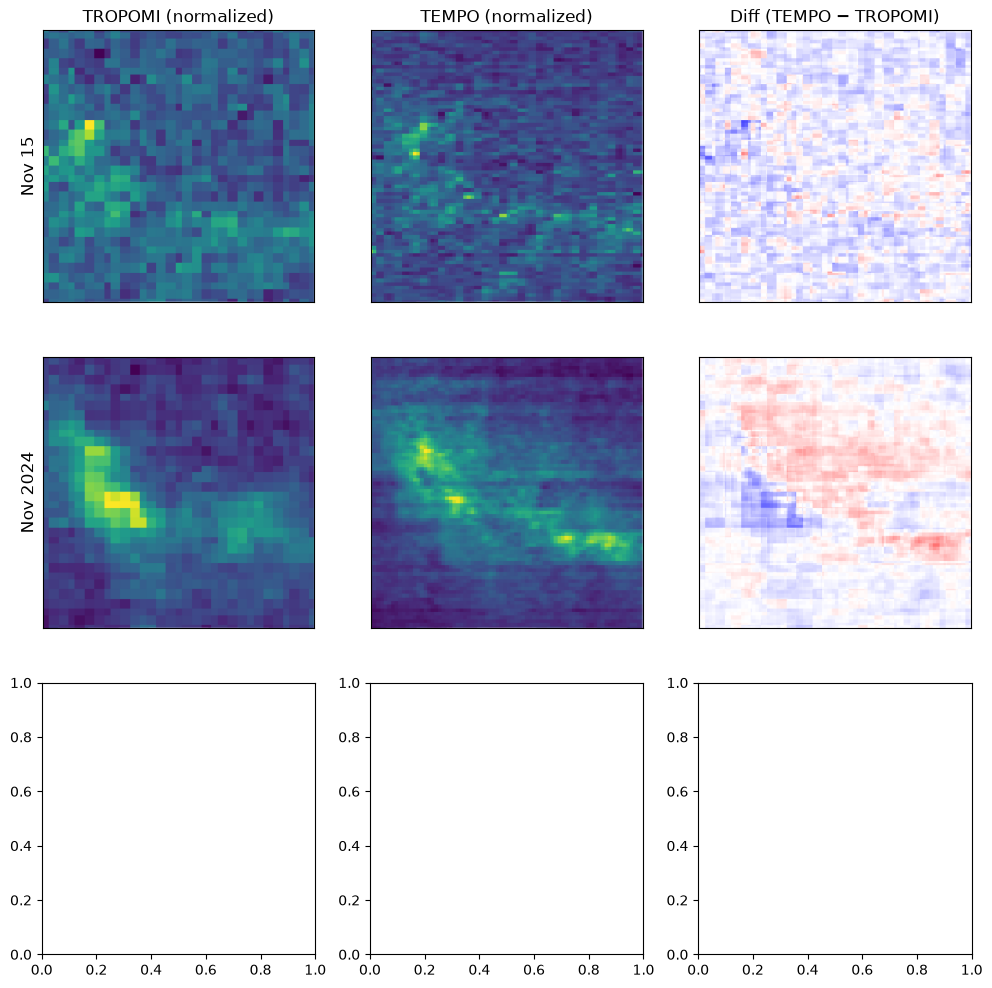

In [27]:
import io
import time
import urllib.request
from PIL import Image as PILImage


def fetch_thumb(img, vis_params, dimensions=400, retries=4):
    url = img.getThumbURL({**vis_params, 'region': study_area, 'dimensions': dimensions, 'format': 'png'})
    for attempt in range(retries):
        try:
            with urllib.request.urlopen(url, timeout=60) as resp:
                return PILImage.open(io.BytesIO(resp.read()))
        except Exception:
            if attempt == retries - 1:
                raise
            time.sleep(2 ** attempt)


thumb_norm = {'min': 0, 'max': 1, 'palette': palette}
thumb_diff = {'min': -1, 'max': 1, 'palette': ['blue', 'white', 'red']}

grid_rows = [
    ('Nov 15', tropomi_day_scaled, tempo_day_scaled, diff_norm_day),
    ('Nov 2024', tropomi_monthly_scaled, tempo_monthly_scaled, diff_norm_monthly),
    ('2024 Annual', tropomi_annual_scaled, tempo_annual_scaled, diff_norm_annual),
]
col_titles = ['TROPOMI (normalized)', 'TEMPO (normalized)', 'Diff (TEMPO − TROPOMI)']

fig, axes = plt.subplots(len(grid_rows), 3, figsize=(12, 12))

for row_idx, (row_label, tropomi_img, tempo_img, diff_img) in enumerate(grid_rows):
    thumbs = [
        fetch_thumb(tropomi_img.clip(study_area), thumb_norm),
        fetch_thumb(tempo_img.clip(study_area), thumb_norm),
        fetch_thumb(diff_img.clip(study_area), thumb_diff),
    ]
    for col_idx, thumb in enumerate(thumbs):
        ax = axes[row_idx, col_idx]
        ax.imshow(thumb)
        ax.set_xticks([])
        ax.set_yticks([])
        if row_idx == 0:
            ax.set_title(col_titles[col_idx])
        if col_idx == 0:
            ax.set_ylabel(row_label, fontsize=12)

plt.tight_layout()
plt.show()

## Raw value diagnostics

In [ ]:
# Filter to images with unmasked pixel data in the region to see the true overpass(es).

def filter_to_valid_data(collection, geometry, band, scale=5500):
    def add_valid_count(img):
        count = img.select(band).reduceRegion(
            reducer=ee.Reducer.count(), geometry=geometry, scale=scale, maxPixels=1e9
        ).get(band)
        return img.set('valid_count', count)
    return collection.map(add_valid_count).filter(ee.Filter.gt('valid_count', 0))


tropomi_nov15_all = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_NO2')
                      .filterDate('2024-11-15', '2024-11-16')
                      .filterBounds(study_area)
                      .map(mask_tropomi))

tropomi_nov15_valid = filter_to_valid_data(
    tropomi_nov15_all, study_area, 'tropospheric_NO2_column_number_density')

print('TROPOMI Nov 15 footprint-intersecting images (misleading — includes empty grazes):',
      tropomi_nov15_all.size().getInfo())

print('TROPOMI Nov 15 actual overpasses (valid data in study area):',
      [pd.to_datetime(t, unit='ms', utc=True).strftime('%Y-%m-%d %H:%M') for t in
       tropomi_nov15_valid.aggregate_array('system:time_start').getInfo()])

print('TROPOMI Nov 15 image count with valid data:', tropomi_nov15_valid.size().getInfo())

In [24]:
raw_tropomi = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_NO2')
               .filterDate('2024-11-01', '2024-11-30')
               .filterBounds(study_area)
               .map(mask_tropomi)
               .mean())

print('Raw TROPOMI mean (mol/m\u00b2):',
      raw_tropomi.reduceRegion(reducer=ee.Reducer.mean(), geometry=study_area,
                                scale=5500, maxPixels=1e9).getInfo())

print('Raw TEMPO mean (molecules/cm\u00b2):',
      tempo_monthly_agg.reduceRegion(reducer=ee.Reducer.mean(), geometry=study_area,
                                      scale=5500, maxPixels=1e9).getInfo())

print('TROPOMI \u00d710\u00b9\u2074 stats:',
      tropomi_monthly.divide(1e14).reduceRegion(
          reducer=ee.Reducer.mean().combine(ee.Reducer.minMax(), sharedInputs=True),
          geometry=study_area, scale=5500, maxPixels=1e9).getInfo())

print('TROPOMI converted mean:',
      tropomi_monthly.reduceRegion(reducer=ee.Reducer.mean(), geometry=study_area,
                                    scale=5500, maxPixels=1e9).getInfo())

Raw TROPOMI mean (mol/m²): {'tropospheric_NO2_column_number_density': 2.5689652364848547e-05}
Raw TEMPO mean (molecules/cm²): {'vertical_column_troposphere': 2385383900673053}
TROPOMI ×10¹⁴ stats: {'tropospheric_NO2_column_number_density_max': 5.558318703873196, 'tropospheric_NO2_column_number_density_mean': 2.365165364010546, 'tropospheric_NO2_column_number_density_min': 1.1341233945663176}
TROPOMI converted mean: {'tropospheric_NO2_column_number_density': 236516536401055.06}
